# Invariant QPINN on a neutral-atom device (QoolQit)

- **Quantum model.**
  - Step 1 encodes $x$ and $t$ as Pauli-$Z$ rotations.
  - Step 2 is a trainable pulse with **4 parameters**.
- **Hard constraint.** $u_\theta(x,t)=A\cos x+(1-\cos t)\,f(x,t)$, so the initial condition holds for every $\theta$.
- **Invariant QPINN.** $f(x,t)=\tfrac12\big[f_\theta(x,t)+f_\theta(-x,-t)\big]$: each shot runs the circuit at $(x,t)$ or at $(-x,-t)$, chosen at random. This is the randomized encoding of the sign-flip group average (arXiv:2610.01874).
- **Plain QPINN.** $f=f_\theta$, with everything else the same.
- **PDE.** $u_t+u_x=-A\sin(x+t)$ with $u(x,0)=A\cos x$. The exact solution $u^\ast=A\cos x\cos t$ is even.
- **Training.**
  - Derivatives: two-term parameter-shift rule.
  - Optimizer: Levenberg–Marquardt via `scipy.optimize.least_squares(method="lm")`.
  - Runs: one run per model, from the same starting point.
- **Measurement.** Every residual $R_j$, Jacobian entry and value of $f$ is a weighted sum of circuit outputs. It is estimated directly from `SHOTS = 100` shots, each running one circuit of the sum drawn at random (§2.1), instead of estimating every circuit separately.
- **Backend.** All circuits run on the QoolQit emulator.

## 0. Setup

- **Register.** Two atoms at distance 1, so $\tilde J_{01}=1$ (see §1.1). Atom 0 carries $x$, atom 1 carries $t$.
- **Device.** `AnalogDeviceWithDMM`: one global laser plus one detuning map modulator (DMM). With energy unit 1, one time unit is 1 µs.
- **Model size.** Two trainable phase segments (`K = 2`), i.e. 4 parameters.
- **Shots.** `SHOTS = 100`: every estimated quantity uses 100 shots during training (§2.1). `EVAL_SHOTS = 10000`: every value of $f$ in the final evaluation uses 10 000 shots (§6). `RNG` draws which circuit each shot runs.

In [1]:
import json
import os
import time
from functools import reduce

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import least_squares
from qoolqit import Register, Drive, QuantumProgram, AnalogDeviceWithDMM, ConstantWaveform
from qoolqit.drive import DetuningMapModulator
from qoolqit.execution import LocalEmulator, EmulationConfig, BitStrings, Occupation

SHOTS = 100                                # shots per estimated quantity during training (each R_j, each dR_j/dtheta_k)
EVAL_SHOTS = 10000                         # shots per value of f in the final evaluation
RNG = np.random.default_rng(1)             # draws which circuit each shot runs
RESULTS_DIR = "results_invariant_qpinn_randomized"
os.makedirs(RESULTS_DIR, exist_ok=True)

COORDS = [(0.0, 0.0), (1.0, 0.0)]          # atom 0 carries x, atom 1 carries t
J = 1.0 / np.linalg.norm(np.subtract(COORDS[0], COORDS[1])) ** 6   # = 1
T_P, T_E, T_M, T_Z = 0.5, 0.5, 0.4, 0.2   # durations (µs): preparation, encoding, mixing, trainable phase segment
OMEGA_M = (np.pi / 2) / T_M               # each mixing segment is about a pi/2 rotation of every atom
K = 2                                     # trainable phase segments -> 2K = 4 parameters
TWO_PI = 2 * np.pi
SHIFT = np.pi / 2                         # parameter-shift step (all generators have a single gap of 1)
print("total duration =", T_P + T_E + (K + 1) * T_M + K * T_Z, "µs")

register = Register.from_coordinates(COORDS)
device = AnalogDeviceWithDMM()            # AnalogDevice + one detuning map modulator (DMM)
device.set_energy_unit(1.0)               # 1 energy unit = 1 rad/µs  ->  1 time unit = 1 µs

total duration = 2.6 µs


## 1. Quantum model

### 1.1 Hamiltonian and preparation segment

**QoolQit model.** QoolQit writes the Hamiltonian of a neutral-atom register in dimensionless units
$$\tilde{H}(t)=\sum_{i<j}\tilde{J}_{ij}\,\hat{n}_i\hat{n}_j+\sum_i\frac{\tilde{\Omega}(t)}{2}\Big(\cos\phi(t)\,\hat{\sigma}^x_i-\sin\phi(t)\,\hat{\sigma}^y_i\Big)-\sum_i\Big(\tilde{\delta}(t)+\epsilon_i\,\tilde{\Delta}(t)\Big)\hat{n}_i ,$$

where $\hat{n}_i=\tfrac12\big(1+\hat{\sigma}^z_i\big)$ is the Rydberg occupation of atom $i$, and $\tilde{J}_{ij}=\tilde{r}_{ij}^{-6}$ is normalized so that $\max\tilde{J}_{ij}=1$. Here $t$ is pulse time. To avoid a clash with the PDE variable $t$, we write pulse time as $\tau$ from now on.

**Our choices.**

- Two atoms at `COORDS` $=(0,0),(1,0)$, so $\tilde{J}_{01}=1$.
- $\phi=0$ (the `Drive` default), so the drive term is $\tfrac{\tilde\Omega}{2}\hat{\sigma}^x_i$ only.
- $\epsilon_0=1$, $\epsilon_1=0$ (`weights={0: 1.0, 1: 0.0}`): the local detuning acts on atom 0 only.
- $\tilde{\Omega},\tilde{\delta},\tilde{\Delta}$ are constant inside each segment of the schedule (§1.2).

With these choices,

$$\tilde{H}(\tau)=\hat{n}_0\hat{n}_1+\frac{\tilde{\Omega}(\tau)}{2}\big(\hat{\sigma}^x_0+\hat{\sigma}^x_1\big)-\big(\tilde{\delta}(\tau)+\tilde{\Delta}(\tau)\big)\,\hat{n}_0-\tilde{\delta}(\tau)\,\hat{n}_1,\qquad \tilde{\Delta}(\tau)\le 0 .$$

So atom 1 sees the detuning $\tilde\delta$, and atom 0 sees $\tilde\delta+\tilde\Delta$.

**Pauli form.** We follow QoolQit's convention: $X_i=\hat{\sigma}^x_i$ and $Z_i=\hat{\sigma}^z_i=2\hat{n}_i-1$, so $Z_i=+1$ on the Rydberg state and $-1$ on the ground state. Then

$$\tilde{H}(\tau)=\frac{\tilde{\Omega}(\tau)}{2}\big(X_0+X_1\big)+\Big(\frac14-\frac{\tilde{\delta}(\tau)+\tilde{\Delta}(\tau)}{2}\Big)Z_0+\Big(\frac14-\frac{\tilde{\delta}(\tau)}{2}\Big)Z_1+\frac14\,Z_0Z_1+\Big(\frac14-\tilde{\delta}(\tau)-\frac12\tilde{\Delta}(\tau)\Big)\mathbb{1}.$$

The last term only adds a global phase.

We label basis states $|q_0q_1\rangle$ with $q=0$ for the ground state and $q=1$ for the Rydberg state, so $|00\rangle$ means both atoms are in the ground state. `H_matrix` below builds $\tilde H$ as a 4×4 matrix in this basis; it is only used to calibrate $P$.

**Preparation $P$:** a fixed segment with $\tilde{\Delta}=0$. Its constant $(\tilde{\Omega}_P,\tilde{\delta}_P)$ are calibrated so that all four populations of $P|00\rangle$ are $1/4$. Without it, the $Z$ encoding acting on $|00\rangle$ would have no effect.

In [2]:
# The same 2-atom Hamiltonian as a 4x4 matrix (basis |q0 q1> = 00, 01, 10, 11; q = 0 ground, q = 1 Rydberg).
# Used only to calibrate the preparation segment P, once, before any circuit runs.
Xp, nn, I2 = np.array([[0.0, 1.0], [1.0, 0.0]]), np.diag([0.0, 1.0]), np.eye(2)
n0, n1 = np.kron(nn, I2), np.kron(I2, nn)


def H_matrix(omega, delta, Delta=0.0):
    return omega / 2 * (np.kron(Xp, I2) + np.kron(I2, Xp)) - delta * (n0 + n1) - Delta * n0 + J * n0 @ n1


def prep_populations(p):
    return np.abs(expm(-1j * T_P * H_matrix(*p))[:, 0]) ** 2


# choose (Omega_P, delta_P) so that all four populations of P|00> are 1/4
OMEGA_P, DELTA_P = least_squares(lambda p: prep_populations(p) - 0.25, x0=[np.pi / (2 * T_P), 0.3]).x
print(f"Omega_P = {OMEGA_P:.4f}, delta_P = {DELTA_P:.4f}, populations =",
      np.round(prep_populations([OMEGA_P, DELTA_P]), 6))

Omega_P = 3.1473, delta_P = 0.2809, populations = [0.25 0.25 0.25 0.25]


### 1.2 Pulse segments and schedule

The drive is piecewise constant: `make_program` chains `ConstantWaveform`s with `>>`. We call each constant piece a **segment**. Inside a segment of duration $T$, the parameters $(\tilde{\Omega},\tilde{\delta},\tilde{\Delta})$ are constant, so the segment applies $e^{-iT\tilde{H}}$ with the Pauli form of §1.1. Its $\mathbb{1}$ term only gives a global phase, so we drop it:

$$\tilde{H}=\frac{\tilde{\Omega}}{2}\big(X_0+X_1\big)+\Big(\frac14-\frac{\tilde{\delta}+\tilde{\Delta}}{2}\Big)Z_0+\Big(\frac14-\frac{\tilde{\delta}}{2}\Big)Z_1+\frac14\,Z_0Z_1 ,$$

and $\cong$ below means equal up to a global phase. There are three kinds of segments.

**Preparation $P$** (fixed): $T_P=0.5$, $\tilde{\Omega}=\tilde{\Omega}_P$, $\tilde{\delta}=\tilde{\delta}_P$, $\tilde{\Delta}=0$, with $(\tilde{\Omega}_P,\tilde{\delta}_P)$ calibrated in the previous cell:

$$\tilde{H}_P=\frac{\tilde{\Omega}_P}{2}\big(X_0+X_1\big)+\Big(\frac14-\frac{\tilde{\delta}_P}{2}\Big)\big(Z_0+Z_1\big)+\frac14\,Z_0Z_1,\qquad P\cong e^{-iT_P\tilde{H}_P}.$$

**Phase segment $Z(\alpha_0,\alpha_1)$** (`phase_segment`): $\tilde{\Omega}=0$, and $\tilde{\delta},\tilde{\Delta}$ are chosen such that

$$\tilde{\delta}T\equiv \alpha_1,\qquad \big(\tilde{\delta}+\tilde{\Delta}\big)T\equiv \alpha_0 \pmod{2\pi},\qquad \tilde{\Delta}\le 0.$$

The Hamiltonian is diagonal,

$$\tilde{H}_Z=\Big(\frac14-\frac{\alpha_0}{2T}\Big)Z_0+\Big(\frac14-\frac{\alpha_1}{2T}\Big)Z_1+\frac14\,Z_0Z_1 ,$$

where $(\tilde{\delta}+\tilde{\Delta})T$ and $\tilde{\delta}T$ have been replaced by $\alpha_0$ and $\alpha_1$. They differ by a multiple of $2\pi$, which can only flip the sign of $e^{-iT\tilde{H}_Z}$, since $e^{i\pi Z_i}=-\mathbb{1}$. Since the terms of $\tilde{H}_Z$ commute,

$$Z(\alpha_0,\alpha_1)\cong e^{-iT\tilde{H}_Z}=e^{\,\frac{i}{2}(\alpha_0Z_0+\alpha_1Z_1)}\,e^{-i\frac{T}{4}(Z_0+Z_1+Z_0Z_1)}=R_Z\big(\tfrac{T}{2}-\alpha_0\big)\otimes R_Z\big(\tfrac{T}{2}-\alpha_1\big)\cdot e^{-i\frac{T}{4}Z_0Z_1},\qquad R_Z(\alpha)=e^{-i\alpha Z/2}.$$

It is used in two places:

- **Encoding** $E=Z(x,t)$ with $T=T_E=0.5$: $x$ goes to atom 0 and $t$ to atom 1.
- **Trainable** $Z(\theta_0,\theta_1)$ and $Z(\theta_2,\theta_3)$ with $T=T_Z=0.2$.

**Mixing $M$** (fixed): $T_M=0.4$, $\tilde{\Omega}=\tilde{\Omega}_M=\pi/(2T_M)$, $\tilde{\delta}=\tilde{\Delta}=0$:

$$\tilde{H}_M=\frac{\tilde{\Omega}_M}{2}\big(X_0+X_1\big)+\frac14\big(Z_0+Z_1+Z_0Z_1\big),\qquad M\cong e^{-iT_M\tilde{H}_M}.$$

Without the $\tfrac14$ terms, which come from the interaction (§1.1), only the drive is left. Since $X_0$ and $X_1$ commute and $\tilde{\Omega}_MT_M=\pi/2$,

$$e^{-iT_M\frac{\tilde{\Omega}_M}{2}(X_0+X_1)}=e^{-i\frac{\tilde{\Omega}_MT_M}{2}X_0}\,e^{-i\frac{\tilde{\Omega}_MT_M}{2}X_1}=e^{-i\frac{\pi}{4}X_0}\,e^{-i\frac{\pi}{4}X_1}=R_X(\pi/2)\otimes R_X(\pi/2),\qquad R_X(\alpha)=e^{-i\alpha X/2}.$$

$M$ turns the phases written by the phase segments into populations that $Z_0$ can measure, and a $\pi/2$ rotation does this with maximal contrast. The $\tfrac14$ terms are kept in the actual $M$: they couple the two atoms, so that $t$ (atom 1) can affect the measurement on atom 0.

**Schedule** (time order, total 2.6 µs):

| segment | $P$ | $E=Z(x,t)$ | $M$ | $Z(\theta_0,\theta_1)$ | $M$ | $Z(\theta_2,\theta_3)$ | $M$ |
|---|---|---|---|---|---|---|---|
| duration (µs) | 0.5 | 0.5 | 0.4 | 0.2 | 0.4 | 0.2 | 0.4 |

`segments(x, t, theta)` returns this list of segments as tuples $(T,\tilde{\Omega},\tilde{\delta},\tilde{\Delta})$, and `make_program` turns it into a QoolQit `QuantumProgram`.

In [3]:
def phase_segment(alpha0, alpha1, T):
    # Phase segment Z(alpha0, alpha1) of §1.2: Omega = 0, delta T = alpha1, (delta + Delta) T = alpha0 (mod 2pi).
    # Atom 1 feels delta, atom 0 feels delta + Delta. Phases are 2pi-periodic, so we wrap them
    # such that |delta| <= pi/T and Delta <= 0 (the DMM can only detune downwards).
    alpha1 = (alpha1 + np.pi) % TWO_PI - np.pi
    return (T, 0.0, alpha1 / T, -((alpha1 - alpha0) % TWO_PI) / T)      # (duration, Omega, delta, Delta)


MIX = (T_M, OMEGA_M, 0.0, 0.0)


def segments(x, t, theta):
    w = [(T_P, OMEGA_P, DELTA_P, 0.0),    # P: fixed preparation
         phase_segment(x, t, T_E),        # E: step 1, encoding  R_Z(-x) (x) R_Z(-t)
         MIX]                             # step 2, trainable layer: M Z(theta_0, theta_1) M Z(theta_2, theta_3) M
    for alpha0, alpha1 in np.reshape(theta, (K, 2)):
        w += [phase_segment(alpha0, alpha1, T_Z), MIX]
    return w


def chain(durations, values):
    return reduce(lambda w1, w2: w1 >> w2, [ConstantWaveform(float(d), float(v)) for d, v in zip(durations, values)])


def make_program(x, t, theta):
    T, om, de, De = zip(*segments(x, t, theta))
    drive = Drive(amplitude=chain(T, om),
                  detuning=chain(T, de),
                  dmm=DetuningMapModulator(waveform=chain(T, De), weights={0: 1.0, 1: 0.0}))
    return QuantumProgram(register, drive)

### 1.3 Example pulse

$\tilde{\Omega}$, global $\tilde{\delta}$ and DMM $\tilde{\Delta}$ (on atom 0) for one point $(x,t)=(0.8,0.3)$ and a random $\theta$. The horizontal axis is pulse time $\tau$, not the PDE variable $t$.

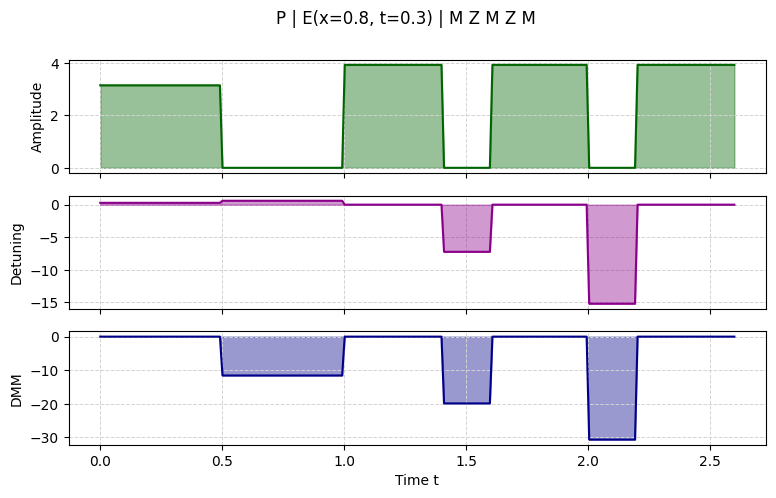

In [4]:
# Pulse schedule for one example point: Omega, global delta, DMM Delta (on atom 0).
# Horizontal axis = pulse time, not the PDE variable t.
theta_ex = np.random.default_rng(0).uniform(-np.pi, np.pi, 2 * K)
plt.figure(figsize=(9, 5))
make_program(0.8, 0.3, theta_ex).drive.draw()
plt.suptitle("P | E(x=0.8, t=0.3) | M Z M Z M")
plt.show()

### 1.4 Circuit output

$$f_\theta(x,t)=\langle00|\,U_\theta^\dagger Z_0U_\theta\,|00\rangle,\qquad U_\theta=M\,Z(\theta_2,\theta_3)\,M\,Z(\theta_0,\theta_1)\,M\;Z(x,t)\;P,$$

so

$$f_\theta(x,t)=\sum_{\omega_x,\omega_t\in\{-1,0,1\}}c_\omega(\theta)\,e^{\,i(\omega_xx+\omega_tt)} .$$

**Circuit.** A circuit is fixed by its input $(x,t)$ and its parameters $\theta$; its output is $f_\theta(x,t)$. `circuit(x, t, theta)` returns this triple, with $x$ wrapped into $[-\pi,\pi)$ since $f$ is $2\pi$-periodic in $x$.

**Measurement.** One shot of a circuit gives a bitstring. Its first bit says whether atom 0 is in the Rydberg state, which is a single-shot value $z=\pm1$ of $Z_0$ with $\mathbb E[z]=f_\theta(x,t)$. `measure(x, t, theta, n)` runs one circuit for `n` shots and returns how many give $z=+1$. It counts circuit runs in `N_RUNS` and shots in `N_SHOTS`.

In [5]:
N_RUNS, N_SHOTS = 0, 0                                  # circuit runs and shots so far


def measure(x, t, theta, n):
    # n shots of one circuit; returns how many give z = +1 for Z_0 (atom 0 in the Rydberg state)
    global N_RUNS, N_SHOTS
    N_RUNS += 1
    N_SHOTS += n
    program = make_program(x, t, theta)
    program.compile_to(device)
    emulator = LocalEmulator(emulation_config=EmulationConfig(observables=[BitStrings(num_shots=n)]))
    counts = emulator.run(program).results().final_bitstrings   # Counter: bits ordered (q0, q1), "1" = Rydberg
    return sum(c for bits, c in counts.items() if bits[0] == "1")

## 2. Plain and invariant QPINN

**Plain QPINN:** $f=f_\theta$.

**Invariant QPINN:**

$$f(x,t)=\tfrac12\big[f_\theta(x,t)+f_\theta(-x,-t)\big]=\sum_\omega\mathrm{Re}\,c_\omega(\theta)\,\cos(\omega_xx+\omega_tt),$$

which is invariant under $(x,t)\to(-x,-t)$.

**As circuits.** The plain model is one circuit, $(x,t,\theta)$ with weight 1. The invariant model is the average of two circuits, $(x,t,\theta)$ and $(-x,-t,\theta)$, each with weight $\tfrac12$. `terms_plain` and `terms_inv` return these as lists of (weight, circuit) pairs, called `terms` in the code, and `lin` forms linear combinations of such lists.

In [6]:
def circuit(x, t, theta):
    # the circuit (x, t, theta) of §1.4, with x wrapped into [-pi, pi) since f is 2pi-periodic in x
    return (round((x + np.pi) % TWO_PI - np.pi, 9), round(t, 9), tuple(np.round(theta, 12)))


def terms_plain(x, t, theta):
    # f(x, t) = f_theta(x, t): one circuit with weight 1
    return [(1.0, circuit(x, t, theta))]


def terms_inv(x, t, theta):
    # f(x, t) = [f_theta(x, t) + f_theta(-x, -t)] / 2: two circuits with weight 1/2 (randomized encoding)
    return [(0.5, circuit(x, t, theta)), (0.5, circuit(-x, -t, theta))]


def lin(*parts):
    # sum_k coef_k * terms_k, flattened into one list of (a_i, circuit_i) pairs
    return [(coef * a_i, circuit_i) for coef, terms in parts for a_i, circuit_i in terms]

### 2.1 Randomized estimator

**What is estimated.** Every quantity we need (a value of $f$, a residual $R_j$, a Jacobian entry $\partial R_j/\partial\theta_k$) is a constant $b$ plus a weighted sum of circuit outputs,

$$Q=b+\sum_i a_i\,f_{\theta_i}(x_i,t_i),$$

where term $i$ is the circuit $(x_i,t_i,\theta_i)$ with weight $a_i$. The constant $b$ and the weights are known numbers (§4.3 and §4.4 derive them), and $\|a\|_1=\sum_i|a_i|$.

**One shot.** Instead of measuring every circuit separately, one shot

1. draws one term $i$ with probability $q_i=|a_i|/\|a\|_1$, so terms with large weights are measured more often (dividing by $\|a\|_1$ makes the probabilities sum to 1);
2. runs circuit $(x_i,t_i,\theta_i)$ once and reads $z\in\{+1,-1\}$, with $\mathbb E[z\mid i]=f_{\theta_i}(x_i,t_i)$;
3. records the random variable

$$Y=\|a\|_1\,\operatorname{sign}(a_i)\,z .$$

**Unbiased.** Averaging first over $z$ and then over $i$,

$$\mathbb E[Y]=\sum_i q_i\,\|a\|_1\operatorname{sign}(a_i)\,f_{\theta_i}(x_i,t_i)=\sum_i|a_i|\operatorname{sign}(a_i)\,f_{\theta_i}(x_i,t_i)=\sum_i a_i\,f_{\theta_i}(x_i,t_i).$$

The factor $\|a\|_1$ in $Y$ cancels the $1/\|a\|_1$ in $q_i$, and $\operatorname{sign}(a_i)$ restores the negative weights, such as the minus signs of the shift rules.

**Estimate from $N$ shots.** With $N$ = `SHOTS` independent shots $Y_1,\dots,Y_N$,

$$\hat Q=b+\frac1N\sum_{\ell=1}^{N}Y_\ell,\qquad \mathbb E[\hat Q]=Q .$$

Every shot has $Y^2=\|a\|_1^2$, so $\operatorname{Var}(Y)=\|a\|_1^2-(Q-b)^2$ and

$$\operatorname{Var}(\hat Q)=\frac{\|a\|_1^2-(Q-b)^2}{N}\le\frac{\|a\|_1^2}{N}.$$

So $\|a\|_1$ also sets the precision: the standard deviation of $\hat Q$ is at most $\|a\|_1/\sqrt N$. This is the randomized encoding of arXiv:2610.01874, applied to the whole sum.

### Algorithm: randomized estimation

Implemented by `estimate(quantities, shots)`.

**Input.**

- `quantities`: the set $\mathcal Q$ of all quantities needed at this point. Each $Q\in\mathcal Q$ is a pair `(b, terms)`: its constant $b$ and its list of terms $(a_i,\ (x_i,t_i,\theta_i))$, so that $Q=b+\sum_i a_i\,f_{\theta_i}(x_i,t_i)$. For example, `jacobian` passes $\mathcal Q=\{R_j\}\cup\{\partial R_j/\partial\theta_k\}$, i.e. $16+64=80$ quantities (§4.4), and `residuals` passes $\mathcal Q=\{R_j\}$.
- $N$: the number of shots for each quantity, `SHOTS` unless `shots` is given.

**Output.**

- `Q_hat`: the set of estimates $\{\hat Q:\ Q\in\mathcal Q\}$, in the same order as `quantities`, with $\hat Q=b+\frac1N\sum_{\ell=1}^NY_\ell$ for each $Q$. All of them come from one round of circuit runs (step 2).

**Procedure.** Below, $C$ denotes a circuit $(x,t,\theta)$, and $b$, $a_i$, $\|a\|_1$, $n_i$, $P_i$ always belong to one quantity $Q\in\mathcal Q$.

1. **Allocate the shots** (no circuit is run yet). For every $Q\in\mathcal Q$:
   - compute $\|a\|_1$ (`norm_a`). If $\|a\|_1=0$, the quantity has no circuit and $\hat Q=b$;
   - compute $q_i=|a_i|/\|a\|_1$ (`q`) and draw the counts $(n_1,n_2,\dots)$ (`n`) from the multinomial distribution with $N$ trials and probabilities $q_i$. Here $n_i$ is the number of the quantity's $N$ shots that draw term $i$; drawing the term of all $N$ shots at once gives exactly these counts;
   - add $n_i$ to $n_C$, the total number of shots requested from the circuit $C$ of term $i$ (`shots_per_circuit`). Different quantities can share a circuit, so $n_C$ collects the shots of all of them.
2. **Run every distinct circuit once.** For every circuit $C$, `measure` runs $C$ with $n_C$ shots and returns $P_C$, the number of shots with $z=+1$. `pool` stores $(n_C,P_C)$ for every circuit: its shots not yet given to a term, and how many of them have $z=+1$.
3. **Deal the outcomes back.** For every $Q\in\mathcal Q$, and every term $i$ of $Q$ with $n_i>0$ and circuit $C$:
   - term $i$ takes $n_i$ of the remaining shots of $C$ at random. The number of them with $z=+1$, called $P_i$, follows the hypergeometric distribution: the number of red balls when $n_i$ balls are drawn without replacement from a bag of $n_C$ balls, $P_C$ of which are red;
   - these shots leave the bag: $n_C\leftarrow n_C-n_i$ and $P_C\leftarrow P_C-P_i$, so every shot is used exactly once;
   - the $n_i$ shots of term $i$ have $P_i$ values $z=+1$ and $n_i-P_i$ values $z=-1$, so their values of $z$ add up to $2P_i-n_i$.

   Every shot of term $i$ has $Y=\|a\|_1\operatorname{sign}(a_i)\,z$, so the quantity's estimate is

$$\hat Q=b+\frac1N\sum_{\ell=1}^NY_\ell=b+\frac{\|a\|_1}{N}\sum_i\operatorname{sign}(a_i)\,\big(2P_i-n_i\big).$$

**Why grouping changes nothing.** The shots of one circuit are independent and identically distributed, so the $n_i$ shots that term $i$ receives in step 3 are distributed exactly like $n_i$ shots run for term $i$ alone. Grouping only reduces the number of emulator runs to one per distinct circuit.

In [7]:
def estimate(quantities, shots=None):
    # quantities: list of (b, terms), terms = [(a_i, circuit_i), ...], i.e. Q = b + sum_i a_i f(circuit_i).
    # Returns Q_hat = b + ||a||_1 / N * sum_i sign(a_i) (2 P_i - n_i) for every quantity (§2.1).
    N = SHOTS if shots is None else shots

    # 1. For every quantity, draw n_i: how many of its N shots draw term i (probability q_i).
    plans = []                   # per quantity: (b, ||a||_1, [(sign(a_i), circuit_i, n_i), ...])
    shots_per_circuit = {}       # circuit -> shots requested by all quantities together
    for b, terms in quantities:
        a = np.array([a_i for a_i, _ in terms])
        norm_a = np.abs(a).sum()                                   # ||a||_1
        if norm_a == 0:                                            # no circuit: Q = b
            plans.append((b, 0.0, []))
            continue
        q = np.abs(a) / norm_a                                     # q_i
        n = RNG.multinomial(N, q)                                  # n_i
        draws = [(np.sign(a_i), circuit_i, int(n_i)) for (a_i, circuit_i), n_i in zip(terms, n) if n_i > 0]
        plans.append((b, norm_a, draws))
        for _, circuit_i, n_i in draws:
            shots_per_circuit[circuit_i] = shots_per_circuit.get(circuit_i, 0) + n_i

    # 2. Run every distinct circuit once, with all the shots it received.
    pool = {circuit_i: [n_c, measure(*circuit_i, n_c)]           # [shots left, z = +1 outcomes left]
            for circuit_i, n_c in shots_per_circuit.items()}

    # 3. Deal the outcomes back. P_i = number of z = +1 among the n_i shots of term i.
    Q_hat = []
    for b, norm_a, draws in plans:
        total = 0                                                  # sum_i sign(a_i) (2 P_i - n_i)
        for sign_a_i, circuit_i, n_i in draws:
            n_left, plus_left = pool[circuit_i]
            P_i = RNG.hypergeometric(plus_left, n_left - plus_left, n_i)
            pool[circuit_i] = [n_left - n_i, plus_left - P_i]
            total += sign_a_i * (2 * P_i - n_i)
        Q_hat.append(b + norm_a * total / N)
    return np.array(Q_hat)

## 3. Derivatives

Both models are degree-1 trigonometric polynomials in $x$, in $t$ and in each $\theta_k$, all with gap 1. So the two-term shift rule with a shift of $\pi/2$ is exact:

$$\partial_xf=\tfrac12\Big[f\big(x+\tfrac\pi2,t\big)-f\big(x-\tfrac\pi2,t\big)\Big],\qquad \partial_tf=\tfrac12\Big[f\big(x,t+\tfrac\pi2\big)-f\big(x,t-\tfrac\pi2\big)\Big],$$

$$\partial_{\theta_k}f_\theta(x,t)=\tfrac12\Big[f_{\theta+\frac\pi2e_k}(x,t)-f_{\theta-\frac\pi2e_k}(x,t)\Big],$$

where $\theta\pm\tfrac\pi2e_k$ shifts only $\theta_k$. `d_theta` applies the $\theta$ rule to a weighted sum of circuits: every circuit $(x,t,\theta)$ is replaced by $(x,t,\theta+\tfrac\pi2e_k)$ and $(x,t,\theta-\tfrac\pi2e_k)$ with half its weight and opposite signs, so $\|a\|_1$ is unchanged.

The check below estimates the three shift rules and central finite differences with step $h=0.05$ at one point (invariant model), each with `SHOTS` shots. A finite difference has $\|a\|_1=1/h$, so its shot noise is up to $1/(h\sqrt N)=2$ here, and the two columns agree only within that noise.

In [8]:
def shift(circuit_i, k, s):
    # the same circuit with theta_k shifted by s
    x, t, theta = circuit_i
    theta = np.array(theta, dtype=float)
    theta[k] += s
    return circuit(x, t, theta)


def d_theta(terms, k):
    # terms of d/dtheta_k: every (a_i, circuit_i) becomes (+a_i/2, theta_k + pi/2) and (-a_i/2, theta_k - pi/2)
    return [(a_i * sign / 2, shift(circuit_i, k, sign * SHIFT)) for a_i, circuit_i in terms for sign in (1, -1)]


# Check the shift rules against central finite differences at one point (invariant model).
# Every number is estimated with SHOTS shots; the finite difference amplifies the noise by 1/(2h).
x0, t0, h = 0.7, 0.4, 0.05
e0 = np.eye(2 * K)[0]
F = terms_inv
fd = 1 / (2 * h)
quantities = [
    (0.0, lin((0.5, F(x0 + SHIFT, t0, theta_ex)), (-0.5, F(x0 - SHIFT, t0, theta_ex)))),
    (0.0, lin((fd, F(x0 + h, t0, theta_ex)), (-fd, F(x0 - h, t0, theta_ex)))),
    (0.0, lin((0.5, F(x0, t0 + SHIFT, theta_ex)), (-0.5, F(x0, t0 - SHIFT, theta_ex)))),
    (0.0, lin((fd, F(x0, t0 + h, theta_ex)), (-fd, F(x0, t0 - h, theta_ex)))),
    (0.0, d_theta(F(x0, t0, theta_ex), 0)),
    (0.0, lin((fd, F(x0, t0, theta_ex + h * e0)), (-fd, F(x0, t0, theta_ex - h * e0)))),
]
est = estimate(quantities)
for name, psr, fdiff in zip(["df/dx      ", "df/dt      ", "df/dtheta_0"], est[0::2], est[1::2]):
    print(f"{name}  PSR {psr:+.5f}   finite diff {fdiff:+.5f}")

df/dx        PSR -0.66000   finite diff -2.00000
df/dt        PSR -0.02000   finite diff -1.20000
df/dtheta_0  PSR -0.08000   finite diff -2.00000


## 4. PDE, hard constraint and loss

### 4.1 PDE

$$u_t+u_x=-A\sin(x+t),\qquad x\in[-\pi,\pi)\ \text{(periodic)},\quad t\in[0,1],\qquad u(x,0)=A\cos x,\qquad A=0.5,$$

$$u^\ast(x,t)=A\cos x\cos t .$$

In [9]:
A = 0.5


def u_exact(x, t):
    return A * np.cos(x) * np.cos(t)

### 4.2 Hard constraint

$$u_\theta(x,t)=A\cos x+(1-\cos t)\,f(x,t).$$

- Since $1-\cos 0=0$, $u_\theta(x,0)=A\cos x$ for every $\theta$, so the loss contains only the PDE residual.
- $1-\cos t$ is even in $t$, so it does not break the symmetry of the invariant model.
- Periodicity in $x$ is automatic.

`u_theta` evaluates $u_\theta$ from values of $f$ (used in §6).

**Why the invariant model should do better.** The exact solution corresponds to $f^\ast=-A\cos x$.

- The invariant model contains only cosine terms. It has to match 4 cosine coefficients with 4 parameters.
- The plain model must also make its 4 sine coefficients vanish, which is 8 conditions for 4 parameters.

In [10]:
def u_theta(f_values, x, t):
    # hard constraint: u_theta = A cos x + (1 - cos t) f
    return A * np.cos(x) + (1 - np.cos(t)) * f_values

### 4.3 Residual and loss

**Residual.** The PDE of §4.1 has the residual $r=u_t+u_x+A\sin(x+t)$. With the hard constraint of §4.2,

$$\partial_tu_\theta=\sin t\,f+(1-\cos t)\,f_t,\qquad \partial_xu_\theta=-A\sin x+(1-\cos t)\,f_x,$$

so

$$r=\sin t\,f+(1-\cos t)\,(f_t+f_x)-A\sin x+A\sin(x+t).$$

**Shift rules in $x$ and $t$.** Substituting $f_t$ and $f_x$ from §3, $r$ contains only values of $f$ and a constant:

$$r=\sin t\,f(x,t)+\frac{1-\cos t}{2}\Big[f\big(x,t+\tfrac\pi2\big)-f\big(x,t-\tfrac\pi2\big)+f\big(x+\tfrac\pi2,t\big)-f\big(x-\tfrac\pi2,t\big)\Big]-A\sin x+A\sin(x+t).$$

**Loss.** On the 16 collocation points $(x_j,t_j)$,

$$\mathcal L=\frac1{16}\sum_j r(x_j,t_j)^2=\sum_j R_j^2,\qquad R_j=\frac{r(x_j,t_j)}{4}.$$

**$R_j$ as a weighted sum of circuits.** For the plain model each $f$ is one circuit, so $R_j$ has 5 circuits:

| $i$ | circuit | weight $a_{ji}$ |
|---|---|---|
| 1 | $(x_j,\ t_j,\ \theta)$ | $\sin t_j/4$ |
| 2 | $(x_j,\ t_j+\tfrac\pi2,\ \theta)$ | $+(1-\cos t_j)/8$ |
| 3 | $(x_j,\ t_j-\tfrac\pi2,\ \theta)$ | $-(1-\cos t_j)/8$ |
| 4 | $(x_j+\tfrac\pi2,\ t_j,\ \theta)$ | $+(1-\cos t_j)/8$ |
| 5 | $(x_j-\tfrac\pi2,\ t_j,\ \theta)$ | $-(1-\cos t_j)/8$ |

Writing circuit $i$ as $(x_{ji},t_{ji},\theta)$,

$$R_j=b_j+\sum_{i}a_{ji}\,f_\theta(x_{ji},t_{ji}),\qquad b_j=\frac{A\big[\sin(x_j+t_j)-\sin x_j\big]}{4},\qquad \|a_j\|_1=\frac{\sin t_j+2(1-\cos t_j)}{4}.$$

For the invariant model every row splits into two circuits, $(x_{ji},t_{ji},\theta)$ and $(-x_{ji},-t_{ji},\theta)$, each with half the weight. That gives 10 circuits with the same $b_j$ and the same $\|a_j\|_1$.

`residual_terms` builds $b_j$ and the circuits row by row from this table, and `residuals` estimates every $R_j$ with `SHOTS` shots (§2.1), so the standard deviation of $\hat R_j$ is at most $\|a_j\|_1/\sqrt N$.

**Collocation points.** $x\in\{-\pi,-\tfrac\pi2,0,\tfrac\pi2\}$ and $t\in\{0.25,0.5,0.75,1\}$. The $x$-shifts land on grid points, so neighbouring residuals share circuits, and `estimate` runs each distinct circuit once per call.

**Bias of the recorded loss.** $\mathbb E[\hat R_j^2]=R_j^2+\operatorname{Var}(\hat R_j)$, so $\hat R\cdot\hat R$ is biased upward by $\sum_j\operatorname{Var}(\hat R_j)$.

In [11]:
x_col = np.linspace(-np.pi, np.pi, 4, endpoint=False)          # spacing pi/2 = SHIFT
t_col = np.array([0.25, 0.5, 0.75, 1.0])
colloc = [(x, t) for t in t_col for x in x_col]                 # 16 collocation points (x_j, t_j)


def residual_terms(terms, x, t, theta):
    # R_j = b_j + sum_i a_ji f(x_ji, t_ji), row by row as in the table of §4.3.
    # `terms` is terms_plain or terms_inv, so for the invariant model every row gives two circuits.
    b = A * (np.sin(x + t) - np.sin(x)) / 4
    a = [np.sin(t) / 4, (1 - np.cos(t)) / 8, -(1 - np.cos(t)) / 8, (1 - np.cos(t)) / 8, -(1 - np.cos(t)) / 8]
    xt = [(x, t), (x, t + SHIFT), (x, t - SHIFT), (x + SHIFT, t), (x - SHIFT, t)]
    return b, lin(*[(a_i, terms(x_i, t_i, theta)) for a_i, (x_i, t_i) in zip(a, xt)])


def residuals(theta, terms, history):
    # every R_j estimated with SHOTS shots (§2.1)
    return estimate([residual_terms(terms, x, t, theta) for x, t in colloc])

### 4.4 Jacobian

LM also needs the Jacobian $J=\partial R/\partial\theta$. Applying the $\theta$ shift rule of §3 to every circuit of $R_j$ (the constant $b_j$ drops out),

$$\frac{\partial R_j}{\partial\theta_k}=\sum_i a_{ji}\,\partial_{\theta_k}f_\theta(x_{ji},t_{ji})=\sum_i\Big[\frac{a_{ji}}{2}\,f_{\theta+\frac\pi2e_k}(x_{ji},t_{ji})-\frac{a_{ji}}{2}\,f_{\theta-\frac\pi2e_k}(x_{ji},t_{ji})\Big].$$

So $\partial R_j/\partial\theta_k$ is again a weighted sum of circuits, without a constant: every circuit $(x_{ji},t_{ji},\theta)$ of $R_j$ is replaced by $(x_{ji},t_{ji},\theta+\tfrac\pi2e_k)$ with weight $+a_{ji}/2$ and $(x_{ji},t_{ji},\theta-\tfrac\pi2e_k)$ with weight $-a_{ji}/2$. That gives 10 circuits for the plain model and 20 for the invariant one, and the absolute weights still sum to $\|a_j\|_1$. `d_theta` builds this list from the terms of $R_j$.

`jacobian` builds the terms of every $R_j$ (`R_terms`) and of every $\partial R_j/\partial\theta_k$ (`J_terms`), and estimates $R$ (16 numbers) and $J$ (64 numbers) in one batch, each with `SHOTS` shots (§2.1), and records the loss $\hat R\cdot\hat R$ of every LM iterate. LM then computes its step from $\hat J$ and $\hat R$.

**Cost of one Jacobian.**

- $80\times$ `SHOTS` $=8000$ shots for both models.
- They spread over at most 432 distinct circuits (plain) or 864 (invariant), which bounds the number of emulator runs.
- Estimating every circuit separately with 100 shots, as in the previous notebook, took 43 200 and 86 400 shots.

In [12]:
def jacobian(theta, terms, history):
    # R (16 numbers) and J = dR/dtheta (64 numbers) estimated in one batch, SHOTS shots each (§2.1).
    # The loss R . R of every LM iterate is stored in `history`.
    R_terms = [residual_terms(terms, x, t, theta) for x, t in colloc]                     # (b_j, terms of R_j)
    J_terms = [(0.0, d_theta(terms_j, k)) for _, terms_j in R_terms for k in range(len(theta))]   # no constant
    estimates = estimate(R_terms + J_terms)
    R = estimates[:len(colloc)]
    J = estimates[len(colloc):].reshape(len(colloc), len(theta))
    history.append(float(R @ R))
    return J

### 4.5 Accuracy of randomized estimation

We compare randomized estimation with the exact values for the plain model, at the example parameters $\theta$ of §1.3 (`theta_ex`). The quantities are the same as in one `jacobian` call: the 16 residuals $R_j$ and the 64 Jacobian entries $\partial R_j/\partial\theta_k$.

For every quantity $Q$ there are three numbers:

- **exact**: the exact value $Q=b+\sum_i a_i\,f_{\theta_i}(x_i,t_i)$, with every $f_{\theta_i}(x_i,t_i)=\langle Z_0\rangle=2\langle\hat n_0\rangle-1$ computed by the QoolQit emulator with the `Occupation` observable, i.e. without shot noise (`exact`, `f_exact`);
- **estimate**: $\hat Q$ from randomized estimation with $N$ = `TEST_SHOTS` shots per quantity (`estimate`). `TEST_SHOTS` is set in the cell below and is used only for this test;
- **error**: $\hat Q-Q$.

The table lists their absolute values averaged over the 16 $R_j$ and over the 64 $\partial R_j/\partial\theta_k$. We average absolute values because the quantities and their errors have both signs, so plain averages would mostly cancel.

By §2.1 the error has mean 0 and standard deviation at most $\|a_j\|_1/\sqrt N$. $R_j$ and all $\partial R_j/\partial\theta_k$ have the same $\|a_j\|_1$ (§4.4), so with $N=100$ this bound is 0.008, 0.018, 0.030 and 0.044 for $t_j=0.25$, 0.5, 0.75 and 1. It decreases as $1/\sqrt N$: 4 times more shots halve it.

In [19]:
exact_emulator = LocalEmulator(emulation_config=EmulationConfig(observables=[Occupation(evaluation_times=[1.0])]))
F_EXACT = {}                                                   # circuit -> exact f, each circuit computed once


def f_exact(circuit_i):
    # exact <Z_0> of one circuit (Occupation observable, no shot noise)
    if circuit_i not in F_EXACT:
        program = make_program(*circuit_i)
        program.compile_to(device)
        n_occ = np.array(exact_emulator.run(program).results().occupation[-1])
        F_EXACT[circuit_i] = 2.0 * n_occ[0] - 1.0             # <Z_0> = 2 <n_0> - 1
    return F_EXACT[circuit_i]


def exact(quantities):
    # Q = b + sum_i a_i f(circuit_i) with exact f, for every (b, terms) in quantities
    return np.array([b + sum(a_i * f_exact(circuit_i) for a_i, circuit_i in terms) for b, terms in quantities])


TEST_SHOTS = 1000                                               # shots per quantity, only for this test

# plain model, the same quantities as one `jacobian` call
R_terms = [residual_terms(terms_plain, x, t, theta_ex) for x, t in colloc]
J_terms = [(0.0, d_theta(terms_j, k)) for _, terms_j in R_terms for k in range(len(theta_ex))]
Q_hat = estimate(R_terms + J_terms, shots=TEST_SHOTS)          # estimate (randomized estimation)
Q = exact(R_terms + J_terms)                                   # exact
R_hat, R_exact = Q_hat[:len(colloc)], Q[:len(colloc)]
dR_hat, dR_exact = Q_hat[len(colloc):], Q[len(colloc):]

print(f"{'average of absolute values':26s} {'exact':>9s} {'estimate':>9s} {'error':>9s}")
for label, exact_values, estimates in [("R_j (16)", R_exact, R_hat), ("dR_j/dtheta_k (64)", dR_exact, dR_hat)]:
    print(f"{label:26s} {np.mean(np.abs(exact_values)):9.4f} {np.mean(np.abs(estimates)):9.4f} "
          f"{np.mean(np.abs(estimates - exact_values)):9.4f}")

average of absolute values     exact  estimate     error
R_j (16)                      0.1378    0.1367    0.0069
dR_j/dtheta_k (64)            0.0283    0.0291    0.0054


## 5. Training

Each model is trained once with `least_squares(method="lm")`.

**Settings.**

- Same starting point $\theta_0$ for both models, drawn uniformly from $[-\pi,\pi)^4$.
- `xtol=1e-6`.
- `max_nfev=10`, which caps each run at fewer than 10 LM iterations. Rejected trial steps also use up evaluations, and `xtol` can stop a run earlier, so the two models may end with different iteration counts.

**Shot noise.** Every residual and Jacobian entry is a random estimate (§2.1), and the recorded loss $\hat R\cdot\hat R$ is biased upward by the variance of $\hat R$. LM accepts or rejects a step by comparing noisy losses, so its steps and its stopping are affected by the noise too.

**Recording.** `history` stores the loss at every LM iterate, i.e. at every Jacobian evaluation.

In [14]:
MODELS = {"plain QPINN": terms_plain, "invariant QPINN": terms_inv}
theta0 = np.random.default_rng(0).uniform(-np.pi, np.pi, 2 * K)   # same starting point for both models
runs = []

for name, terms in MODELS.items():
    history = []
    N_RUNS, N_SHOTS = 0, 0
    tic = time.time()
    result = least_squares(residuals, theta0, jac=jacobian, method="lm", xtol=1e-6, max_nfev=10,
                           args=(terms, history))
    if not np.isclose(history[-1], 2 * result.cost):
        history.append(2 * result.cost)           # final iterate, if LM stopped before evaluating its Jacobian
    runs.append(dict(model=name, theta=result.x.tolist(), loss=history,
                     circuit_runs=N_RUNS, shots=N_SHOTS, seconds=time.time() - tic))
    print(f"{name:16s}: final loss {history[-1]:.2e}, {len(history) - 1} LM iterations, "
          f"{N_SHOTS} shots in {N_RUNS} circuit runs, {time.time() - tic:.0f}s")

plain QPINN     : final loss 2.65e-01, 5 LM iterations, 59200 shots in 2708 circuit runs, 155s
invariant QPINN : final loss 3.01e-03, 7 LM iterations, 75200 shots in 6761 circuit runs, 385s


## 6. Evaluation

Each trained model is compared with $u^\ast$ on a 25 × 6 grid over $x\in[-\pi,\pi]$, $t\in[0,1]$. The table lists final loss, max error, LM iterations, circuit runs and shots of the training. Every grid value of $f$ is estimated with `EVAL_SHOTS` shots, i.e. with a statistical error of at most $1/\sqrt{10\,000}=0.01$, so the errors include a small amount of shot noise. Both runs are saved to `results_invariant_qpinn_randomized/results.json`.

In [15]:
# Error against the exact solution on a grid (25 x 6 points per run); every f is estimated with EVAL_SHOTS shots
xs = np.linspace(-np.pi, np.pi, 25)
ts = np.linspace(0.0, 1.0, 6)
for rec in runs:
    terms, theta = MODELS[rec["model"]], np.array(rec["theta"])
    f_values = estimate([(0.0, terms(x, t, theta)) for t in ts for x in xs], shots=EVAL_SHOTS).reshape(len(ts), len(xs))
    U = u_theta(f_values, xs[None, :], ts[:, None])
    rec["max_error"] = float(np.abs(U - u_exact(xs[None, :], ts[:, None])).max())
    rec["U"] = U.tolist()

print(f"{'model':16s} {'final loss':>11s} {'max |u - u*|':>13s} {'iterations':>10s} {'circuit runs':>12s} {'shots':>8s}")
for rec in runs:
    print(f"{rec['model']:16s} {rec['loss'][-1]:11.2e} {rec['max_error']:13.2e} "
          f"{len(rec['loss']) - 1:10d} {rec['circuit_runs']:12d} {rec['shots']:8d}")

with open(os.path.join(RESULTS_DIR, "results.json"), "w") as fh:
    json.dump(dict(shots_per_quantity=SHOTS, eval_shots=EVAL_SHOTS, theta0=theta0.tolist(), runs=runs, xs=xs.tolist(), ts=ts.tolist()),
              fh, indent=1)

model             final loss  max |u - u*| iterations circuit runs    shots
plain QPINN         2.65e-01      5.89e-01          5         2708    59200
invariant QPINN     3.01e-03      5.13e-02          7         6761    75200


## 7. Plots

- Loss vs LM iteration for both models, saved as `loss.png`.
- 3D surfaces of the analytical solution $u^\ast$, the invariant QPINN and the plain QPINN on the evaluation grid, with a shared color and $u$ scale, saved as `solution3d.png`.

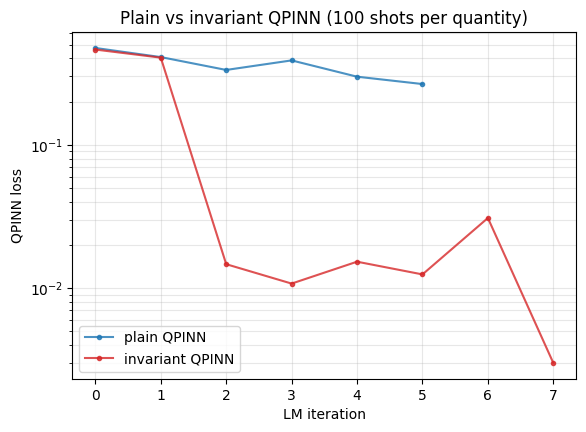

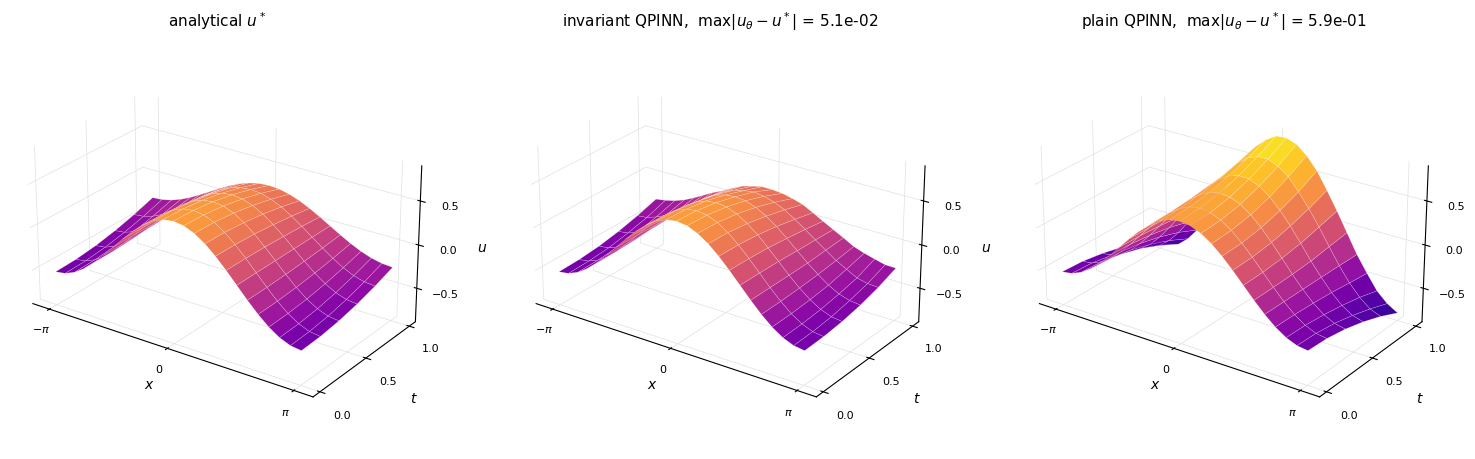

In [16]:
colors = {"plain QPINN": "C0", "invariant QPINN": "C3"}

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for rec in runs:
    ax.semilogy(rec["loss"], "o-", ms=3, color=colors[rec["model"]], alpha=0.8, label=rec["model"])
ax.set_xlabel("LM iteration")
ax.set_ylabel("QPINN loss")
ax.set_title(f"Plain vs invariant QPINN ({SHOTS} shots per quantity)")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.savefig(os.path.join(RESULTS_DIR, "loss.png"), dpi=150, bbox_inches="tight")
plt.show()

XS, TS = np.meshgrid(xs, ts)                                    # same 25 x 6 grid as the evaluation
surfaces = [(r"analytical $u^*$", u_exact(XS, TS))]
for name in ["invariant QPINN", "plain QPINN"]:
    rec = next(r for r in runs if r["model"] == name)
    surfaces.append((name + rf",  $\max|u_\theta-u^*|$ = {rec['max_error']:.1e}", np.array(rec["U"])))
lim = 1.05 * max(np.abs(U).max() for _, U in surfaces)          # shared color and z scale

with plt.rc_context({"grid.color": "0.88", "grid.linewidth": 0.5, "axes.labelsize": 10}):
    fig = plt.figure(figsize=(15, 4.6))
    for k, (title, U) in enumerate(surfaces):
        a = fig.add_subplot(1, 3, k + 1, projection="3d")
        a.plot_surface(XS, TS, U, cmap="plasma", vmin=-lim, vmax=lim,
                       edgecolor=(1.0, 1.0, 1.0, 0.4), linewidth=0.3, antialiased=True)
        a.view_init(elev=25, azim=-55)
        a.set_box_aspect((1.8, 1.0, 0.9))                        # x is the long direction
        for axis in (a.xaxis, a.yaxis, a.zaxis):
            axis.set_pane_color((1.0, 1.0, 1.0, 0.0))            # transparent background panes
        a.set_xticks([-np.pi, 0, np.pi])
        a.set_xticklabels([r"$-\pi$", "0", r"$\pi$"])
        a.set_yticks([0, 0.5, 1])
        a.set_zticks([-A, 0, A])
        a.set_zlim(-lim, lim)
        for axis_name in "xyz":
            a.tick_params(axis=axis_name, labelsize=8)
        a.set_xlabel("$x$")
        a.set_ylabel("$t$")
        a.set_zlabel("$u$")
        a.set_title(title, fontsize=11)
    fig.subplots_adjust(left=0.0, right=1.0, bottom=0.02, top=0.92, wspace=0.02)
    fig.savefig(os.path.join(RESULTS_DIR, "solution3d.png"), dpi=150, bbox_inches="tight")
    plt.show()